## Lab Assignment 6 — Feature Extraction and Machine Learning with Image and Text Data

# Part A — Image Feature Extraction and Classification

In [5]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 0.8/44.0 MB 5.6 MB/s eta 0:00:08
    --------------------------------------- 0.8/44.0 MB 5.6 MB/s eta 0:00:08
    --------------------------------------- 1.0/44.0 MB 2.3 MB/s eta 0:00:19
   - -------------------------------------- 1.3/44.0 MB 1.5 MB/s eta 0:00:30
   - -------------------------------------- 1.3/44.0 MB 1.5 MB/s eta 0:00:30
   - -------------------------------------- 1.6/44.0 MB 1.2 MB/s eta 0:00:35
   - -------------------------------------- 1.6/44.0 MB 1.2 MB/s eta 0:00:35
   - -------------------------------------- 1.8/44.0 MB 1.1 MB/s eta 0:00:40
   - -------------------------------------- 1.8/44.0 MB 1.1 MB/s eta 0:00:40
   - -------------------------------------- 2.1/44.0 MB 962.8 kB/s eta 0:00:44
   - -------------------------------------- 2.1/44.0 MB 962.8 kB/s eta 0:00:44
   -- ------------------------------------- 2.4/44.0 MB 895.1 kB/s eta 0:00:47



[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Import Required Libraries

In [6]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
# Path to the image dataset
image_dataset_path = "D:/Dhirubhai Ambani University/ML/Lab 6/Part A (Image processing)/Datasets"

# Paths to the two classes
crack_path = os.path.join(image_dataset_path, "Cracks")
noncrack_path = os.path.join(image_dataset_path, "NonCracks")

print("Dataset path:", image_dataset_path)
print("Cracks path:", crack_path)
print("NonCracks path:", noncrack_path)

print("\nCracks folder exists:", os.path.exists(crack_path))
print("NonCracks folder exists:", os.path.exists(noncrack_path))

Dataset path: D:/Dhirubhai Ambani University/ML/Lab 6/Part A (Image processing)/Datasets
Cracks path: D:/Dhirubhai Ambani University/ML/Lab 6/Part A (Image processing)/Datasets\Cracks
NonCracks path: D:/Dhirubhai Ambani University/ML/Lab 6/Part A (Image processing)/Datasets\NonCracks

Cracks folder exists: True
NonCracks folder exists: True


### 3. Inspect the Image Dataset

In [8]:
# Get image filenames from both class folders
crack_files = [
    f for f in os.listdir(crack_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

noncrack_files = [
    f for f in os.listdir(noncrack_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

print("Number of crack images:", len(crack_files))
print("Number of non-crack images:", len(noncrack_files))
print("Total images:", len(crack_files) + len(noncrack_files))

print("\nSample crack filenames:")
print(crack_files[:5])

print("\nSample non-crack filenames:")
print(noncrack_files[:5])

Number of crack images: 200
Number of non-crack images: 200
Total images: 400

Sample crack filenames:
['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg', 'IMG_20180513_165345878_HDR resized_448.jpg', 'IMG_20180513_165349788_HDR resized_448.jpg']

Sample non-crack filenames:
['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg']


### 4. Inspect Image Dimensions and Channels

In [9]:
# Select one sample image from each class
sample_crack_path = os.path.join(crack_path, crack_files[0])
sample_noncrack_path = os.path.join(noncrack_path, noncrack_files[0])

# Read images using OpenCV
sample_crack = cv2.imread(sample_crack_path)
sample_noncrack = cv2.imread(sample_noncrack_path)

# Display image information
print("Crack image:")
print("  Filename:", crack_files[0])
print("  Shape:", sample_crack.shape)
print("  Height:", sample_crack.shape[0])
print("  Width:", sample_crack.shape[1])
print("  Channels:", sample_crack.shape[2])

print("\nNon-crack image:")
print("  Filename:", noncrack_files[0])
print("  Shape:", sample_noncrack.shape)
print("  Height:", sample_noncrack.shape[0])
print("  Width:", sample_noncrack.shape[1])
print("  Channels:", sample_noncrack.shape[2])

Crack image:
  Filename: IMG_20180513_164959951_HDR resized_448.jpg
  Shape: (448, 448, 3)
  Height: 448
  Width: 448
  Channels: 3

Non-crack image:
  Filename: IMG_20180705_130729936 resized_448.jpg
  Shape: (448, 448, 3)
  Height: 448
  Width: 448
  Channels: 3


### 5. Visualize Sample Images

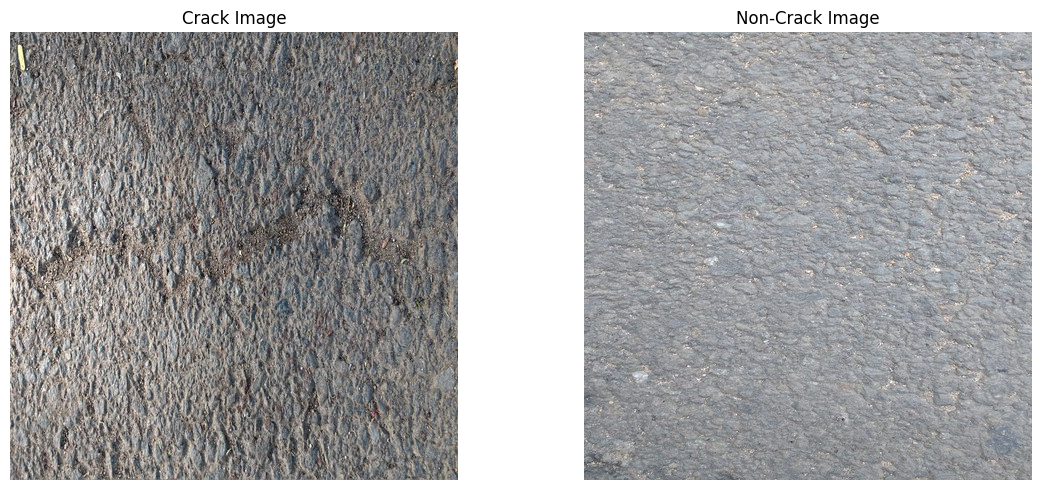

In [10]:
# Convert BGR images to RGB for Matplotlib
sample_crack_rgb = cv2.cvtColor(sample_crack, cv2.COLOR_BGR2RGB)
sample_noncrack_rgb = cv2.cvtColor(sample_noncrack, cv2.COLOR_BGR2RGB)

# Display sample images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_crack_rgb)
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_noncrack_rgb)
plt.title("Non-Crack Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### 6. Image Preprocessing — Resizing and Grayscale Conversion

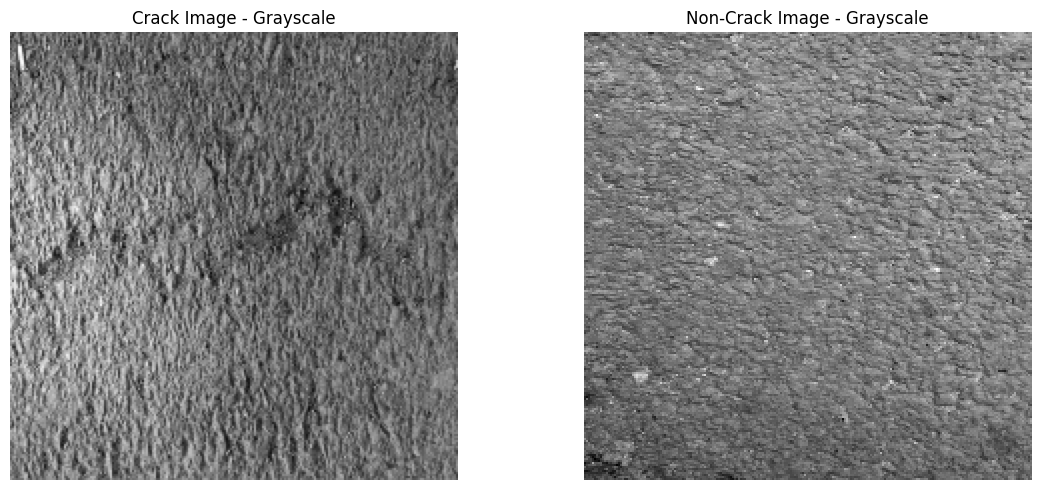

Crack grayscale shape: (224, 224)
Non-crack grayscale shape: (224, 224)


In [11]:
# Common image dimensions
image_size = (224, 224)  # Width x Height

# Resize the sample images
sample_crack_resized = cv2.resize(sample_crack, image_size)
sample_noncrack_resized = cv2.resize(sample_noncrack, image_size)

# Convert resized images to grayscale
sample_crack_gray = cv2.cvtColor(sample_crack_resized, cv2.COLOR_BGR2GRAY)
sample_noncrack_gray = cv2.cvtColor(sample_noncrack_resized, cv2.COLOR_BGR2GRAY)

# Display the grayscale images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_crack_gray, cmap="gray")
plt.title("Crack Image - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_noncrack_gray, cmap="gray")
plt.title("Non-Crack Image - Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

# Display shapes
print("Crack grayscale shape:", sample_crack_gray.shape)
print("Non-crack grayscale shape:", sample_noncrack_gray.shape)

### 7. Intensity-Based Feature Extraction

In [12]:
def extract_intensity_features(gray_image):
    """
    Extract intensity-based features from a grayscale image.
    """

    # Convert pixel values to float for numerical calculations
    pixels = gray_image.astype(np.float32)

    # Intensity thresholds
    dark_threshold = 50
    bright_threshold = 200

    # Calculate intensity features
    mean_brightness = np.mean(pixels)
    contrast = np.std(pixels)

    dark_pixel_ratio = np.mean(pixels < dark_threshold)
    bright_pixel_ratio = np.mean(pixels > bright_threshold)

    min_intensity = np.min(pixels)
    max_intensity = np.max(pixels)
    median_intensity = np.median(pixels)

    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity
    }

In [13]:
# Extract features from the sample images
crack_intensity_features = extract_intensity_features(sample_crack_gray)
noncrack_intensity_features = extract_intensity_features(sample_noncrack_gray)

print("Crack image features:")
for feature, value in crack_intensity_features.items():
    print(f"{feature}: {value:.4f}")

print("\nNon-crack image features:")
for feature, value in noncrack_intensity_features.items():
    print(f"{feature}: {value:.4f}")

Crack image features:
mean_brightness: 122.2246
contrast: 31.5135
dark_pixel_ratio: 0.0038
bright_pixel_ratio: 0.0109
min_intensity: 23.0000
max_intensity: 247.0000
median_intensity: 121.0000

Non-crack image features:
mean_brightness: 157.3580
contrast: 15.4728
dark_pixel_ratio: 0.0000
bright_pixel_ratio: 0.0039
min_intensity: 82.0000
max_intensity: 240.0000
median_intensity: 157.0000


### 8. Canny Edge Detection and Edge-Based Features

In [14]:
def extract_edge_features(gray_image, lower_threshold=50, upper_threshold=150):
    """
    Apply Canny edge detection and extract edge-based features.
    """

    # Apply Canny edge detection
    edges = cv2.Canny(
        gray_image,
        threshold1=lower_threshold,
        threshold2=upper_threshold
    )

    # Count detected edge pixels
    edge_count = np.count_nonzero(edges)

    # Calculate total number of pixels
    total_pixels = edges.size

    # Calculate edge density
    edge_density = edge_count / total_pixels

    return {
        "edge_count": edge_count,
        "edge_density": edge_density
    }, edges

In [15]:
# Extract Canny edge features
crack_edge_features, crack_edges = extract_edge_features(sample_crack_gray)
noncrack_edge_features, noncrack_edges = extract_edge_features(sample_noncrack_gray)

print("Crack image edge features:")
for feature, value in crack_edge_features.items():
    print(f"{feature}: {value:.4f}")

print("\nNon-crack image edge features:")
for feature, value in noncrack_edge_features.items():
    print(f"{feature}: {value:.4f}")

Crack image edge features:
edge_count: 18520.0000
edge_density: 0.3691

Non-crack image edge features:
edge_count: 15721.0000
edge_density: 0.3133


### 9. Visualize Canny Edge Detection

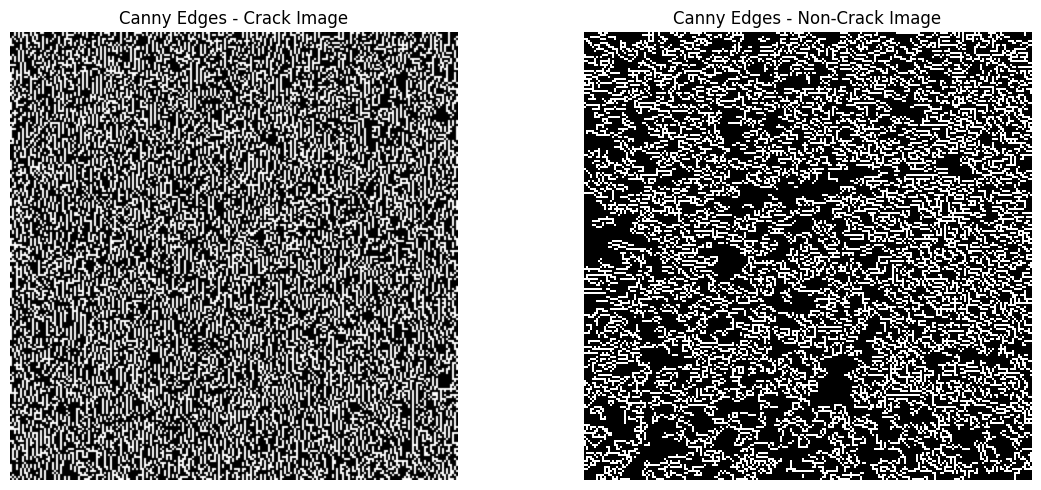

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(crack_edges, cmap="gray")
plt.title("Canny Edges - Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_edges, cmap="gray")
plt.title("Canny Edges - Non-Crack Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### 10. Extract Features from the Complete Image Dataset

In [17]:
# Function to process a single image and extract all required features
def extract_image_features(image_path, label):
    # Read image using OpenCV
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Resize image
    resized_image = cv2.resize(image, image_size)

    # Convert to grayscale
    gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    # Extract intensity features
    intensity_features = extract_intensity_features(gray_image)

    # Extract Canny edge features
    edge_features, _ = extract_edge_features(
        gray_image,
        lower_threshold=50,
        upper_threshold=150
    )

    # Combine all features
    feature_row = {
        "filename": os.path.basename(image_path),
        "label": label
    }

    feature_row.update(intensity_features)
    feature_row.update(edge_features)

    return feature_row

In [18]:
# Store extracted feature rows
image_feature_rows = []

# Process crack images
for filename in crack_files:
    image_path = os.path.join(crack_path, filename)

    features = extract_image_features(
        image_path=image_path,
        label="Crack"
    )

    if features is not None:
        image_feature_rows.append(features)

# Process non-crack images
for filename in noncrack_files:
    image_path = os.path.join(noncrack_path, filename)

    features = extract_image_features(
        image_path=image_path,
        label="NonCrack"
    )

    if features is not None:
        image_feature_rows.append(features)

# Create the final feature DataFrame
image_features_df = pd.DataFrame(image_feature_rows)

print("Feature extraction completed.")
print("Number of rows:", len(image_features_df))
print("Number of columns:", len(image_features_df.columns))

image_features_df.head()

Feature extraction completed.
Number of rows: 400
Number of columns: 11


,filename,label,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,Crack,122.224609,31.513483,0.003846,0.010922,23.0,247.0,121.0,18520,0.369101
1,IMG_20180513_165129852_HDR resized_448.jpg,Crack,131.948685,24.096113,0.002790,0.003787,8.0,251.0,133.0,18094,0.360611
2,IMG_20180513_165150613_HDR resized_448.jpg,Crack,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,17454,0.347856
3,IMG_20180513_165345878_HDR resized_448.jpg,Crack,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,18767,0.374023
4,IMG_20180513_165349788_HDR resized_448.jpg,Crack,131.208878,26.237597,0.002372,0.006258,11.0,254.0,132.0,18349,0.365693


### 11. Validate the Extracted Feature Dataset

In [19]:
# Display all feature columns
print("Feature columns:")
print(image_features_df.columns.tolist())

# Check dataset dimensions
print("\nDataset shape:", image_features_df.shape)

# Check missing values
print("\nMissing values:")
print(image_features_df.isnull().sum())

# Check class distribution
print("\nClass distribution:")
print(image_features_df["label"].value_counts())

# Check data types
print("\nData types:")
print(image_features_df.dtypes)

Feature columns:
['filename', 'label', 'mean_brightness', 'contrast', 'dark_pixel_ratio', 'bright_pixel_ratio', 'min_intensity', 'max_intensity', 'median_intensity', 'edge_count', 'edge_density']

Dataset shape: (400, 11)

Missing values:
filename              0
label                 0
mean_brightness       0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
min_intensity         0
max_intensity         0
median_intensity      0
edge_count            0
edge_density          0
dtype: int64

Class distribution:
label
Crack       200
NonCrack    200
Name: count, dtype: int64

Data types:
filename               object
label                  object
mean_brightness       float32
contrast              float32
dark_pixel_ratio      float64
bright_pixel_ratio    float64
min_intensity         float32
max_intensity         float32
median_intensity      float32
edge_count              int64
edge_density          float64
dtype: object


### 12. Exploratory Analysis of Extracted Image Features

In [20]:
# Select numerical image features
image_feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "edge_count",
    "edge_density"
]

# Calculate class-wise mean values
class_feature_means = (
    image_features_df
    .groupby("label")[image_feature_columns]
    .mean()
    .T
)

class_feature_means

label,Crack,NonCrack
mean_brightness,144.372375,157.632278
contrast,30.006721,23.024330
dark_pixel_ratio,0.007858,0.000298
bright_pixel_ratio,0.068391,0.040841
min_intensity,28.620001,67.360001
max_intensity,251.300003,250.100006
median_intensity,144.649994,157.335007
edge_count,18376.615000,16974.375000
edge_density,0.366243,0.338297


### 13. Visual Comparison of Selected Image Features

<Figure size 700x500 with 0 Axes>

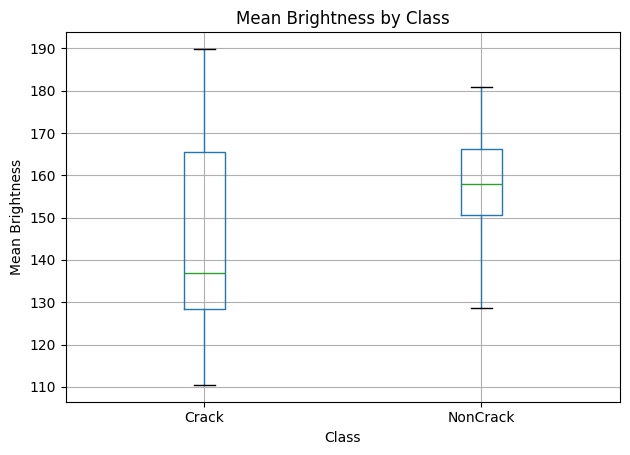

<Figure size 700x500 with 0 Axes>

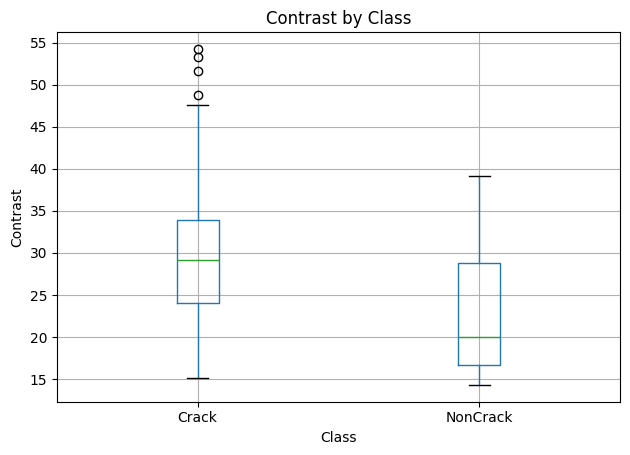

<Figure size 700x500 with 0 Axes>

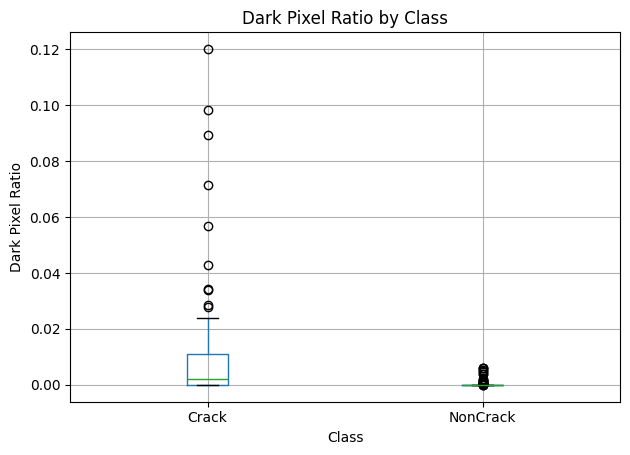

<Figure size 700x500 with 0 Axes>

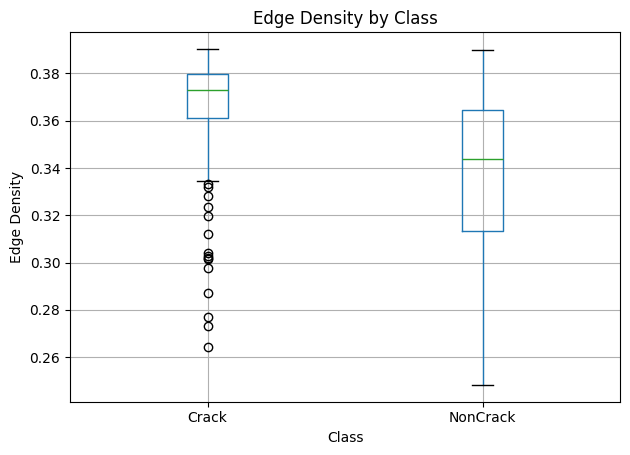

In [22]:
# Features selected for visualization
selected_visual_features = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "edge_density"
]

# Create one plot for each feature
for feature in selected_visual_features:
    plt.figure(figsize=(7, 5))
    
    image_features_df.boxplot(
        column=feature,
        by="label"
    )
    
    plt.title(f"{feature.replace('_', ' ').title()} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(feature.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

### 14. Prepare Data for Machine Learning

In [23]:
# Define input features and target
X_image = image_features_df[image_feature_columns].copy()

# Encode labels: NonCrack = 0, Crack = 1
y_image = image_features_df["label"].map({
    "NonCrack": 0,
    "Crack": 1
})

print("Feature matrix shape:", X_image.shape)
print("Target shape:", y_image.shape)

print("\nClass counts:")
print(y_image.value_counts())

Feature matrix shape: (400, 9)
Target shape: (400,)

Class counts:
label
1    200
0    200
Name: count, dtype: int64


### 15. Train-Test Split

In [24]:
# Split the image dataset into training and testing sets
X_image_train, X_image_test, y_image_train, y_image_test = train_test_split(
    X_image,
    y_image,
    test_size=0.20,
    random_state=42,
    stratify=y_image
)

print("Training feature shape:", X_image_train.shape)
print("Testing feature shape:", X_image_test.shape)

print("\nTraining class distribution:")
print(y_image_train.value_counts())

print("\nTesting class distribution:")
print(y_image_test.value_counts())

Training feature shape: (320, 9)
Testing feature shape: (80, 9)

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing class distribution:
label
0    40
1    40
Name: count, dtype: int64


### 16. Logistic Regression Classifier

In [25]:
# Create Logistic Regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# Measure training time
logistic_start_time = time.perf_counter()

logistic_model.fit(X_image_train, y_image_train)

logistic_training_time = time.perf_counter() - logistic_start_time

# Measure prediction time
logistic_prediction_start_time = time.perf_counter()

y_image_pred_logistic = logistic_model.predict(X_image_test)

logistic_prediction_time = time.perf_counter() - logistic_prediction_start_time

print(f"Training time: {logistic_training_time:.6f} seconds")
print(f"Prediction time: {logistic_prediction_time:.6f} seconds")

Training time: 0.020141 seconds
Prediction time: 0.001128 seconds


### 17. Evaluate Logistic Regression

In [26]:
# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_image_test, y_image_pred_logistic)
logistic_precision = precision_score(y_image_test, y_image_pred_logistic)
logistic_recall = recall_score(y_image_test, y_image_pred_logistic)
logistic_f1 = f1_score(y_image_test, y_image_pred_logistic)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9268
Recall   : 0.9500
F1-score : 0.9383


### 18. Confusion Matrix — Logistic Regression

Confusion Matrix:
[[37  3]
 [ 2 38]]


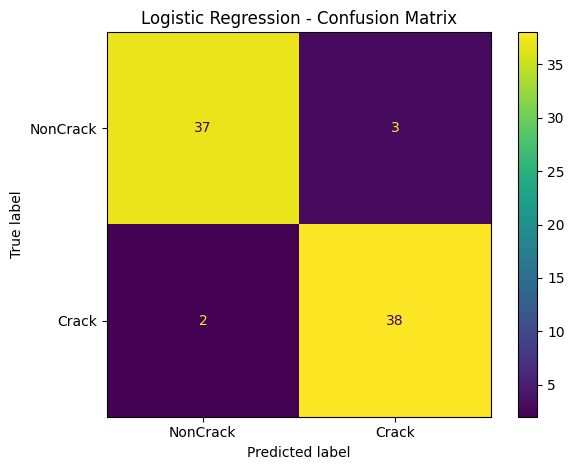

In [27]:
# Calculate confusion matrix
logistic_cm = confusion_matrix(
    y_image_test,
    y_image_pred_logistic
)

print("Confusion Matrix:")
print(logistic_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

### 19. Random Forest Classifier

In [28]:
# Create Random Forest classifier
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Measure training time
rf_start_time = time.perf_counter()

random_forest_model.fit(X_image_train, y_image_train)

rf_training_time = time.perf_counter() - rf_start_time

# Measure prediction time
rf_prediction_start_time = time.perf_counter()

y_image_pred_rf = random_forest_model.predict(X_image_test)

rf_prediction_time = time.perf_counter() - rf_prediction_start_time

print(f"Training time: {rf_training_time:.6f} seconds")
print(f"Prediction time: {rf_prediction_time:.6f} seconds")

Training time: 0.094745 seconds
Prediction time: 0.006377 seconds


### 20. Evaluate Random Forest

In [29]:
# Calculate Random Forest evaluation metrics
rf_accuracy = accuracy_score(y_image_test, y_image_pred_rf)
rf_precision = precision_score(y_image_test, y_image_pred_rf)
rf_recall = recall_score(y_image_test, y_image_pred_rf)
rf_f1 = f1_score(y_image_test, y_image_pred_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9500
Precision: 0.9500
Recall   : 0.9500
F1-score : 0.9500


### 21. Confusion Matrix — Random Forest

Random Forest Confusion Matrix:
[[38  2]
 [ 2 38]]


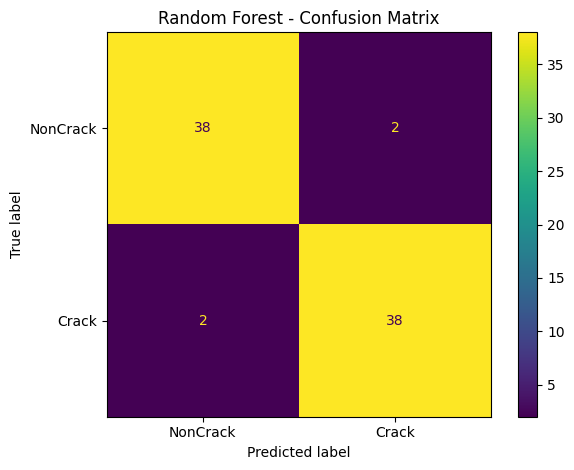

In [30]:
# Calculate confusion matrix
rf_cm = confusion_matrix(
    y_image_test,
    y_image_pred_rf
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()

plt.show()

### 22. Comparison of Image Classification Models

In [31]:
# Create a comparison table for the image classifiers
image_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "Training Time (s)": [
        logistic_training_time,
        rf_training_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time
    ]
})

image_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9375,0.926829,0.95,0.938272,0.020141,0.001128
1,Random Forest,0.9500,0.950000,0.95,0.950000,0.094745,0.006377


### 23. Decision Tree Classifier

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Measure training time
dt_start_time = time.perf_counter()

decision_tree_model.fit(X_image_train, y_image_train)

dt_training_time = time.perf_counter() - dt_start_time

# Measure prediction time
dt_prediction_start_time = time.perf_counter()

y_image_pred_dt = decision_tree_model.predict(X_image_test)

dt_prediction_time = time.perf_counter() - dt_prediction_start_time

print(f"Training time: {dt_training_time:.6f} seconds")
print(f"Prediction time: {dt_prediction_time:.6f} seconds")

Training time: 0.002407 seconds
Prediction time: 0.001113 seconds


### 24. Evaluate Decision Tree

In [33]:
# Calculate Decision Tree evaluation metrics
dt_accuracy = accuracy_score(y_image_test, y_image_pred_dt)
dt_precision = precision_score(y_image_test, y_image_pred_dt)
dt_recall = recall_score(y_image_test, y_image_pred_dt)
dt_f1 = f1_score(y_image_test, y_image_pred_dt)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")

Decision Tree Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9487
Recall   : 0.9250
F1-score : 0.9367


### 25. Confusion Matrix — Decision Tree

Decision Tree Confusion Matrix:
[[38  2]
 [ 3 37]]


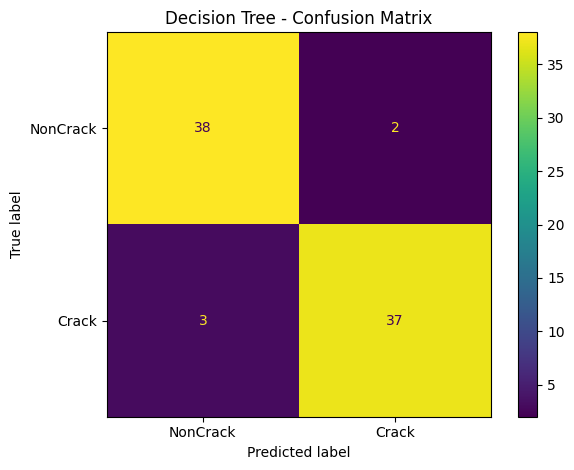

In [34]:
# Calculate confusion matrix
dt_cm = confusion_matrix(
    y_image_test,
    y_image_pred_dt
)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

### 26. Support Vector Machine (SVM)

In [35]:
from sklearn.svm import SVC

# Create SVM pipeline
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

# Measure training time
svm_start_time = time.perf_counter()

svm_model.fit(X_image_train, y_image_train)

svm_training_time = time.perf_counter() - svm_start_time

# Measure prediction time
svm_prediction_start_time = time.perf_counter()

y_image_pred_svm = svm_model.predict(X_image_test)

svm_prediction_time = time.perf_counter() - svm_prediction_start_time

print(f"Training time: {svm_training_time:.6f} seconds")
print(f"Prediction time: {svm_prediction_time:.6f} seconds")

Training time: 0.006356 seconds
Prediction time: 0.002253 seconds


### 27. Evaluate Support Vector Machine (SVM)

In [36]:
# Calculate SVM evaluation metrics
svm_accuracy = accuracy_score(y_image_test, y_image_pred_svm)
svm_precision = precision_score(y_image_test, y_image_pred_svm)
svm_recall = recall_score(y_image_test, y_image_pred_svm)
svm_f1 = f1_score(y_image_test, y_image_pred_svm)

print("SVM Results")
print("-" * 35)
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-score : {svm_f1:.4f}")

SVM Results
-----------------------------------
Accuracy : 0.9375
Precision: 0.9268
Recall   : 0.9500
F1-score : 0.9383


### 28. Confusion Matrix — SVM

SVM Confusion Matrix:
[[37  3]
 [ 2 38]]


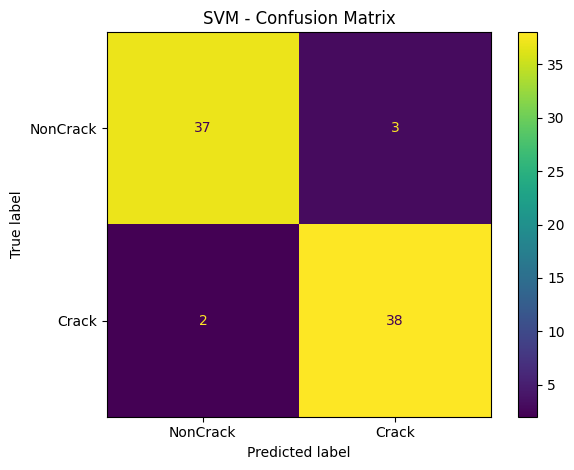

In [37]:
# Calculate confusion matrix
svm_cm = confusion_matrix(
    y_image_test,
    y_image_pred_svm
)

print("SVM Confusion Matrix:")
print(svm_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

### 29. Final Comparison of Image Classification Models

In [38]:
# Final comparison of all image classification models
image_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        dt_recall,
        svm_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1,
        dt_f1,
        svm_f1
    ],
    "Training Time (s)": [
        logistic_training_time,
        rf_training_time,
        dt_training_time,
        svm_training_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time,
        dt_prediction_time,
        svm_prediction_time
    ]
})

image_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9375,0.926829,0.950,0.938272,0.020141,0.001128
1,Random Forest,0.9500,0.950000,0.950,0.950000,0.094745,0.006377
2,Decision Tree,0.9375,0.948718,0.925,0.936709,0.002407,0.001113
3,SVM,0.9375,0.926829,0.950,0.938272,0.006356,0.002253


### 30. Part A — Observations

## Part B — Text Vectorization and Spam Classification

### 31. Load the Email Dataset

In [41]:
# Load the email dataset
email_dataset_path = "D:/Dhirubhai Ambani University/ML/Lab 6/Part B (Text processing)/Dataset/emails.csv"

emails_df = pd.read_csv(email_dataset_path)

print("Dataset shape:", emails_df.shape)

print("\nColumn names:")
print(emails_df.columns.tolist())

print("\nFirst five rows:")
display(emails_df.head())

Dataset shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'h

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


### 32. Inspect the Email Dataset Structure

In [42]:
# Inspect the first and last columns of the dataset

print("First 10 columns:")
print(emails_df.columns[:10].tolist())

print("\nLast 10 columns:")
print(emails_df.columns[-10:].tolist())

print("\nLast 5 rows and columns:")
display(emails_df.iloc[:, -10:].head())

print("\nData types of the last 10 columns:")
print(emails_df.iloc[:, -10:].dtypes)

First 10 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou']

Last 10 columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']

Last 5 rows and columns:


,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0



Data types of the last 10 columns:
connevey          int64
jay               int64
valued            int64
lay               int64
infrastructure    int64
military          int64
allowing          int64
ff                int64
dry               int64
Prediction        int64
dtype: object


### 33. Inspect the Email Labels and Existing Representation

In [43]:
# Inspect the target column
print("Prediction value counts:")
print(emails_df["Prediction"].value_counts())

print("\nUnique Prediction values:")
print(emails_df["Prediction"].unique())

# Inspect Email No.
print("\nFirst 10 Email No. values:")
print(emails_df["Email No."].head(10).tolist())

# Inspect the range of word-count features
email_word_columns = [
    col for col in emails_df.columns
    if col not in ["Email No.", "Prediction"]
]

print("\nNumber of existing word features:", len(email_word_columns))

print("\nSample word features:")
print(email_word_columns[:20])

print("\nSample values from word features:")
display(emails_df[email_word_columns[:10]].head())

Prediction value counts:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Unique Prediction values:
[0 1]

First 10 Email No. values:
['Email 1', 'Email 2', 'Email 3', 'Email 4', 'Email 5', 'Email 6', 'Email 7', 'Email 8', 'Email 9', 'Email 10']

Number of existing word features: 3000

Sample word features:
['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with']

Sample values from word features:


,the,to,ect,and,for,of,a,you,hou,in
0,0,0,1,0,0,0,2,0,0,0
1,8,13,24,6,6,2,102,1,27,18
2,0,0,1,0,0,0,8,0,0,4
3,0,5,22,0,5,1,51,2,10,1
4,7,6,17,1,5,2,57,0,9,3


### 34. Dataset Representation Note

The supplied `emails.csv` contains 5,172 email records represented using 3,000 word-frequency features, along with an `Email No.` identifier and a `Prediction` target.

The original email text is not present in this CSV. Therefore, conventional text cleaning operations on raw email strings cannot be directly performed on the supplied file.

To satisfy the vectorization requirement of the assignment, the existing word-frequency representation will be converted into a reconstructed token representation and processed using `CountVectorizer` and `TfidfVectorizer`.

This reconstruction is based on the supplied word-frequency data and should not be interpreted as recovery of the original email text.

### 35. Spam and Non-Spam Class Distribution

Email class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


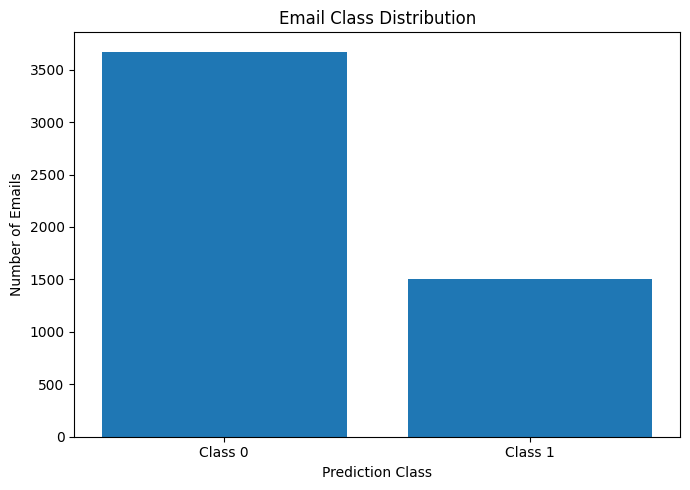

In [44]:
# Display class counts
email_class_counts = emails_df["Prediction"].value_counts().sort_index()

print("Email class distribution:")
print(email_class_counts)

# Visualize class distribution
plt.figure(figsize=(7, 5))

plt.bar(
    ["Class 0", "Class 1"],
    [
        email_class_counts.get(0, 0),
        email_class_counts.get(1, 0)
    ]
)

plt.title("Email Class Distribution")
plt.xlabel("Prediction Class")
plt.ylabel("Number of Emails")

plt.tight_layout()
plt.show()

### 36. Reconstruct Text Representation from Word Frequencies

In [45]:
# Columns containing the existing vocabulary
email_word_columns = [
    col for col in emails_df.columns
    if col not in ["Email No.", "Prediction"]
]

# Reconstruct a token-based text representation
def reconstruct_email_text(row):
    tokens = []

    for word in email_word_columns:
        count = int(row[word])

        if count > 0:
            tokens.extend([word] * count)

    return " ".join(tokens)


# Apply reconstruction to all emails
email_text_reconstructed = emails_df.apply(
    reconstruct_email_text,
    axis=1
)

print("Number of reconstructed emails:", len(email_text_reconstructed))

print("\nExample reconstructed email:")
print(email_text_reconstructed.iloc[0][:1000])

Number of reconstructed emails: 5172

Example reconstructed email:
ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


### 37. Train-Test Split for Email Classification

In [46]:
# Prepare email target
y_email = emails_df["Prediction"]

# Split reconstructed text and target
email_text_train, email_text_test, y_email_train, y_email_test = train_test_split(
    email_text_reconstructed,
    y_email,
    test_size=0.20,
    random_state=42,
    stratify=y_email
)

print("Training emails:", len(email_text_train))
print("Testing emails:", len(email_text_test))

print("\nTraining class distribution:")
print(y_email_train.value_counts())

print("\nTesting class distribution:")
print(y_email_test.value_counts())

Training emails: 4137
Testing emails: 1035

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


### 38. CountVectorizer Representation

In [47]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
count_vectorizer = CountVectorizer()

# Fit only on training data
count_train = count_vectorizer.fit_transform(email_text_train)

# Transform test data using the learned vocabulary
count_test = count_vectorizer.transform(email_text_test)

print("CountVectorizer representation")
print("-" * 40)
print("Training matrix shape:", count_train.shape)
print("Testing matrix shape :", count_test.shape)

print("\nNumber of generated features:", len(count_vectorizer.get_feature_names_out()))

CountVectorizer representation
----------------------------------------
Training matrix shape: (4137, 2974)
Testing matrix shape : (1035, 2974)

Number of generated features: 2974


### 39. Logistic Regression with CountVectorizer

In [48]:
# Create Logistic Regression model for CountVectorizer
count_lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Measure training time
count_lr_start_time = time.perf_counter()

count_lr_model.fit(count_train, y_email_train)

count_lr_training_time = time.perf_counter() - count_lr_start_time

# Measure prediction time
count_lr_prediction_start_time = time.perf_counter()

y_email_pred_count = count_lr_model.predict(count_test)

count_lr_prediction_time = time.perf_counter() - count_lr_prediction_start_time

print(f"Training time: {count_lr_training_time:.6f} seconds")
print(f"Prediction time: {count_lr_prediction_time:.6f} seconds")

Training time: 0.246212 seconds
Prediction time: 0.000939 seconds


### 40. Evaluate CountVectorizer + Logistic Regression

In [49]:
# Calculate evaluation metrics
count_accuracy = accuracy_score(
    y_email_test,
    y_email_pred_count
)

count_precision = precision_score(
    y_email_test,
    y_email_pred_count
)

count_recall = recall_score(
    y_email_test,
    y_email_pred_count
)

count_f1 = f1_score(
    y_email_test,
    y_email_pred_count
)

print("CountVectorizer + Logistic Regression Results")
print("-" * 50)
print(f"Accuracy : {count_accuracy:.4f}")
print(f"Precision: {count_precision:.4f}")
print(f"Recall   : {count_recall:.4f}")
print(f"F1-score : {count_f1:.4f}")

CountVectorizer + Logistic Regression Results
--------------------------------------------------
Accuracy : 0.9807
Precision: 0.9545
Recall   : 0.9800
F1-score : 0.9671


### 41. Confusion Matrix — CountVectorizer

CountVectorizer Confusion Matrix:
[[721  14]
 [  6 294]]


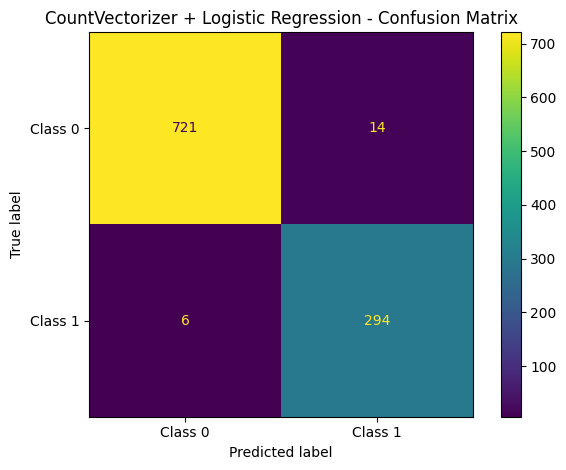

In [50]:
# Calculate confusion matrix
count_cm = confusion_matrix(
    y_email_test,
    y_email_pred_count
)

print("CountVectorizer Confusion Matrix:")
print(count_cm)

# Visualize confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=count_cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("CountVectorizer + Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()